# Spoken Wiki attentional word recognition pilot task results

In [44]:
import pickle
import numpy as np 
import re 
from pathlib import Path
import pandas as pd
import json
import pickle

%matplotlib inline 

import matplotlib.pyplot as plt 
import seaborn as sns
# from matplotlib.ticker import FormatStrFormatter



### Get model results

In [45]:
## import class maps
import pickle
## load WSN vocab mapping 
word_and_speaker_encodings = pickle.load( open( "/om2/user/imgriff/projects/Auditory-Attention/word_and_speaker_encodings_jsinv3.pckl", "rb" )) 
wsn_word_2_class = word_and_speaker_encodings['word_to_idx']
wsn_class_2_word = word_and_speaker_encodings['word_idx_to_word']

cv_word_2_class = pickle.load( open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", "rb" )) 
cv_class_2_word = {v:k for k,v in cv_word_2_class.items()}


### Load human data

In [46]:
path_to_human_data = Path('/mindhive/mcdermott/www/imgriff/msjspsych/')
# !ls {path_to_human_data}
# full paths to .json files 
human_fnames = list(path_to_human_data.glob("cocktail_party_unfamiliar_distractor/data/*.json"))

# import vocab dict for matching audio & responses 
# word_and_speaker_encodings = pickle.load( open("/om2/user/imgriff/projects/Auditory-Attention/word_and_speaker_encodings_jsinv3.pckl", "rb" )) 
# # ix_to_word_map = {v:k for k,v in class_map.items()}
# class_map = word_and_speaker_encodings['word_idx_to_word']
len(human_fnames)


101

In [47]:
# human_fnames

In [48]:
## Get all subject data into one df for analysis

def get_part_df(fname):
    part_data = json.load(open(fname, 'r'))
    # print(f"{fname.stem} success {part_data[0]['success']}")
    part_df = pd.DataFrame.from_records(part_data)
    ## Forward fill stim presentation entry to word response entry
    responses = part_df.loc[part_df.trial_type.isin(['audio-keyboard-response','dictionary-text']), ['trial_index', 'stimulus']]
    responses = responses.ffill()
    part_df.loc[part_df['trial_index'].isin(responses["trial_index"].values), 'stimulus'] = responses.stimulus
    return part_df

dfs = []
for fname in human_fnames:
    try:
        dfs.append(get_part_df(fname))
    except Exception as e:
        print(e)
        print(fname)
    
# results_df = pd.concat([get_part_df(fname) for fname in human_fnames], axis=0, ignore_index=True)
results_df = pd.concat(dfs)
print(results_df.id_subject.nunique())
## Filter for those who passed headphone check 
results_df = results_df[results_df.hc_passed == True]
print(results_df.id_subject.nunique())


## Add snr and condition names as columns - unpack from file code in file names 

import re
### Get condition map
with open('/om/user/imgriff/datasets/human_distractor_language_2024/human_distractor_language_cond_map.pkl', 'rb') as f:
    stim_cond_map = pickle.load(f)

stim_cond_map = {f"condition_{k:02}": v for k,v in stim_cond_map.items()}

## Map wav str to stim_type using condition dict
def get_stim_snr_and_cond(stim_str, stim_cond_map=stim_cond_map):
    cond, snr = None,  None 
    if isinstance(stim_str, str) and not stim_str.startswith('<'):
        # print(stim_str)
        cond_str = re.search("condition_(-?\d+)", stim_str)
        if cond_str:
            cond_str = cond_str.group(0)
            cond, snr = stim_cond_map[cond_str]
            cond = cond.split('_')[0]
        elif 'catch' in stim_str:
            snr = 'inf'
            cond = 'catch_trial'
    return cond, snr

# add as columns 
results_df['distractor_language'], results_df['snr'] = zip(*results_df['stimulus'].apply(get_stim_snr_and_cond))
results_df.loc[results_df['distractor_language'] == 'SILENCE', 'distractor_language'] = 'clean'
# cut down df to only have trial answers (remove other meta data)
expmnt_trial_str = "dictionary-text"
trial_results = results_df[results_df.trial_type == expmnt_trial_str]


# screen based on completion 
total_trials = 172 
full_run_subjects = [subj_id for subj_id, did_all_trials in (trial_results.groupby('id_subject').distractor_language.count() == total_trials).items() if did_all_trials == True]
trial_results = trial_results[trial_results.id_subject.isin(full_run_subjects)]

# # Add accuracy 
trial_results['accuracy'] = (trial_results['response'] == trial_results['correct_response']).astype('int')


Unterminated string starting at: line 1 column 59920 (char 59919)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_unfamiliar_distractor/data/subj_62b44f66a16d45783569fad6.json
Unterminated string starting at: line 1 column 168069 (char 168068)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_unfamiliar_distractor/data/subj_5ceebfea7a3448001a6dd6ee.json
Unterminated string starting at: line 1 column 83947 (char 83946)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_unfamiliar_distractor/data/subj_5f6152406f6e560f32b0cfe4.json
Expecting ',' delimiter: line 1 column 96010 (char 96009)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_unfamiliar_distractor/data/subj_660dc1de10dfc100ea46a7bc.json
Unterminated string starting at: line 1 column 156040 (char 156039)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_unfamiliar_distractor/data/subj_605ab9d5c01d0b0fc69930c5.json
Expecting property name enclosed in double quotes: line 1 column 84002 (char 84

In [163]:
trial_results['accuracy'] = (trial_results['response_str'] == trial_results['correct_response']).astype('int')
catch_trial_particiapnt_performance = trial_results[trial_results.distractor_language == 'catch_trial'].groupby('id_subject').accuracy.mean()

print("N total participants ", len(catch_trial_particiapnt_performance))
good_participants = catch_trial_particiapnt_performance[catch_trial_particiapnt_performance >= 10/12].index
print("N good participants ", len(good_participants))

good_results = trial_results[trial_results.id_subject.isin(good_participants)]
analysis_df = good_results[(~good_results.distractor_language.isnull()) & (~good_results.response.isna())]
# analysis_df.groupby('id_subject').distractor_language.count()

N total participants  51
N good participants  44


#### Add meta to participant df 


In [164]:
manifests = pd.read_pickle('/om/user/imgriff/datasets/human_distractor_language_2024/human_expmt_manifest_w_transcripts.pdpkl')


In [165]:
analysis_df['trial_int'] = analysis_df.stimulus.apply(lambda x: int(x.split('/')[-1].split('.')[0]))

In [166]:
manifests.columns

Index(['target_sr', 'experiment_key_target_word_ix', 'cue_sr', 'target_fn',
       'cue_fn', 'word', 'word_int', 'condition', 'snr', 'src_ix', 'client_id',
       'target_gender', 'target_f0', 'distractor_fn', 'distractor_f0',
       'distractor_gender', 'distractor_word', 'mixture_fn',
       'target_transcripts', 'distractor_transcripts',
       'zh_distractor_client_id', 'zh_distractor_gender',
       'zh_distractor_src_fn', 'nl_distractor_client_id',
       'nl_distractor_gender', 'nl_distractor_src_fn', 'nl_distractor_corpus',
       'zh_distractor_corpus'],
      dtype='object')

In [167]:
### Look at 1 talker sex conditions

manifests = pd.read_pickle('/om/user/imgriff/datasets/human_distractor_language_2024/human_expmt_manifest_w_transcripts.pdpkl')

## Will add columns 'base_str', 'target_gender', 'target_f0', 'distractor_f0', 'distractor_gender' from manifests to trial_results where trial_results.stimulus == manifests.base_str

analysis_df = pd.merge(analysis_df,
                        manifests[['experiment_key_target_word_ix',  'target_gender', 'target_f0', 'distractor_f0', 'distractor_gender', 'distractor_word', 'target_transcripts', 'distractor_transcripts']],
                                    left_on='trial_int', right_on='experiment_key_target_word_ix', how='left')
analysis_df['confusions'] = (analysis_df.response == analysis_df.distractor_word).astype('int')

# add adjusted accuracy and confusions 
pred_words = analysis_df.response.values
target_words = analysis_df.correct_response.values
target_transcripts = analysis_df.target_transcripts.values
distractor_transcripts = analysis_df.distractor_transcripts.values
distractor_words = analysis_df.distractor_word.values


adjusted_acc = np.array([int(pred_word in target_transcript or pred_word == target_words)
                            if not isinstance(target_transcript, float) else np.nan
                             for pred_word, target_words, target_transcript in zip(pred_words, target_words, target_transcripts)
                              ])

adjusted_confs = np.array([int(pred_word in distractor_transcript or pred_word == distractor_word)
                            if not isinstance(distractor_transcript, float) else np.nan
                             for pred_word, distractor_word, distractor_transcript in zip(pred_words, distractor_words, distractor_transcripts)
                              ])

analysis_df['adjusted_accuracy'] = adjusted_acc
analysis_df['adjusted_confusions'] = adjusted_confs

analysis_df['sex_cond'] = analysis_df.apply(lambda row: 'Same sex distractor' if row['target_gender'] == row['distractor_gender'] else 'Different sex distractor', axis=1)


In [168]:
# analysis_df.loc[analysis_df.catch_trial == 1 , 'adjusted_accuracy'] = analysis_df.loc[analysis_df.catch_trial == 1, 'accuracy'] 

In [169]:
analysis_df.columns

Index(['success', 'timeout', 'failed_images', 'failed_audio', 'failed_video',
       'trial_type', 'trial_index', 'time_elapsed', 'internal_node_id',
       'output_filename', 'id_random', 'id_study', 'id_subject', 'id_session',
       'id_version', 'hc_passed', 'view_history', 'rt', 'response',
       'question_order', 'stimulus', 'stim_type', 'hc_answer', 'hc_correct',
       'response_str', 'catch_trial', 'correct_response', 'trial_num',
       'correct', 'n_correct', 'n_incorrect', 'distractor_language', 'snr',
       'accuracy', 'trial_int', 'experiment_key_target_word_ix',
       'target_gender', 'target_f0', 'distractor_f0', 'distractor_gender',
       'distractor_word', 'target_transcripts', 'distractor_transcripts',
       'confusions', 'adjusted_accuracy', 'adjusted_confusions', 'sex_cond'],
      dtype='object')

In [170]:
# get trial data excluding catch trials 
analysis_df = analysis_df[analysis_df.catch_trial == 0]

part_summary_df = (analysis_df.groupby(["snr", 'id_subject', "distractor_language", 'sex_cond', 'target_gender'])
                     .agg({
                            # 'correct':['mean', 'sem'],
                            # 'confusions':['mean', 'sem'],
                            'adjusted_accuracy':['mean', 'count'],
                            'adjusted_confusions':['mean']})
                     .reset_index())

part_summary_df['snr'] = part_summary_df['snr'].replace(np.inf, 6)
part_summary_df['snr'] =  part_summary_df['snr'].replace("inf", 6)
part_summary_df['snr'] = part_summary_df['snr'].astype('int')
# flatten multiindex 
part_summary_df.columns = ['_'.join(col).strip() for col in part_summary_df.columns.values]
# remove trailing underscore
part_summary_df.columns = [col[:-1] if col.endswith('_') else col for col in part_summary_df.columns.values]

# just call adjusted measures the name of the measure 
part_summary_df.rename(columns={'adjusted_accuracy_mean': 'accuracy',
				"adjusted_accuracy_count": 'count',
				'adjusted_confusions_mean': "confusions",
				'target_gender':'gender'}, inplace=True)


In [171]:
part_summary_df

,snr,id_subject,distractor_language,sex_cond,gender,accuracy,count,confusions
0,-9,56366e43dc62e50011cb4ca1,dutch,Different sex distractor,female,1.000000,3,0.0
1,-9,56366e43dc62e50011cb4ca1,dutch,Different sex distractor,male,0.333333,3,0.0
2,-9,56366e43dc62e50011cb4ca1,dutch,Same sex distractor,female,1.000000,2,0.0
3,-9,56366e43dc62e50011cb4ca1,dutch,Same sex distractor,male,0.500000,2,0.0
4,-9,56366e43dc62e50011cb4ca1,english,Different sex distractor,female,0.666667,3,0.0
...,...,...,...,...,...,...,...,...
2658,6,660f023145ab57272958aaa0,clean,Same sex distractor,female,1.000000,3,0.0
2659,6,660f023145ab57272958aaa0,clean,Same sex distractor,male,1.000000,2,0.0
2660,6,66131cf497c722e7c66752d5,clean,Different sex distractor,male,1.000000,4,0.0
2661,6,66131cf497c722e7c66752d5,clean,Same sex distractor,female,0.666667,3,0.0


### If using short stim set experiment model results

In [172]:
# # Path to results 
# # output_paths = list(Path("binaural_eval/word_task_voice_loc_cue_only_v04").glob("*.pkl")) old path for more locations

# # match human pilot conditions
# # model_name = 'word_task_standard_v08'
# model_names = ['word_task_half_co_loc_v07']
# # model_name = 'word_task_quarter_co_loc_v08'
# # model_name = 'word_task_25p_loc_v07_LN_last_valid_time_no_affine'

# # output_paths = list(Path(f"/om2/user/rphess/Auditory-Attention/binaural_eval/human_pilot_conds/{model_name}").glob("*.pkl"))
# # stim_manifest_df = pd.read_pickle('/om/user/imgriff/datasets/human_distractor_language_2024/final_stim_manifest_w_cue_tg_lang_dists.pdpkl')
# stim_manifest_df = pd.read_pickle('/om/user/imgriff/datasets/human_distractor_language_2024/human_expmt_manifest_w_transcripts.pdpkl')

# all_model_results = []

# for model_name in model_names:
#     if "v0" in model_name:
#         output_paths = list(Path(f'unfamiliar_distractor_short/{model_name}').glob('*.csv'))
#         print(len(output_paths))

#     results_dfs = []

#     for path in output_paths:
#         df = pd.read_csv(path)
#         # reformat dict
#         df['model'] = path.parent.name
#         # get language from name
#         if 'english' in path.stem:
#              df['distractor_language'] = 'english'   
#         elif 'mandarin' in path.stem:
#              df['distractor_language'] = 'mandarin'   
#         elif 'dutch' in path.stem:
#              df['distractor_language'] = 'dutch'   

#         print(path.stem)
#         if 'clean' in path.stem or 'inf' in path.stem:
#             df['snr'] =  'inf' # really np.inf, 6 for plotting 
#         else:
#             df['snr'] = int(re.search('(-?\d+)dB', path.stem).group(0).strip('dB'))
        
#         # merge df's on indnex

#         results_dfs.append(df.join(stim_manifest_df.drop(columns='snr')))

#     model_results = pd.concat(results_dfs, axis=0, ignore_index=True)
#     model_results['sex_cond'] = model_results.apply(lambda row: 'Same sex distractor' if row['target_gender'] == row['distractor_gender'] else 'Different sex distractor', axis=1)

#     # model_str = model_name_dict[model_name]
#     # model_results['group'] = model_str

#     class_2_word =  wsn_class_2_word if 'WordSpeakerNoise' in model_name else  cv_class_2_word
#     model_results['pred_word'] = model_results['pred_word_int'].replace(class_2_word)
#     model_results['true_word'] = model_results['true_word_int'].replace(class_2_word)

#     all_model_results.append(model_results)

    
# all_model_results = pd.concat(all_model_results, axis=0, ignore_index=True)
# all_model_results['confusions'] = (all_model_results['pred_word'] ==  all_model_results['distractor_word']).astype('int')

### If using full stim set experiment model results

Is run on all possible stim pairings 

In [173]:
# Path to results 
# output_paths = list(Path("binaural_eval/word_task_voice_loc_cue_only_v04").glob("*.pkl")) old path for more locations

# match human pilot conditions
# model_name = 'word_task_standard_v08'
model_names = ['word_task_half_co_loc_v07', 'word_task_half_co_loc_v08_gender_bal_4M_orig']
# model_name = 'word_task_quarter_co_loc_v08'
# model_name = 'word_task_25p_loc_v07_LN_last_valid_time_no_affine'

# output_paths = list(Path(f"/om2/user/rphess/Auditory-Attention/binaural_eval/human_pilot_conds/{model_name}").glob("*.pkl"))
stim_manifest_df = pd.read_pickle('/om/user/imgriff/datasets/human_distractor_language_2024/final_stim_manifest_w_cue_tg_lang_dists.pdpkl')

all_model_results = []

for model_name in model_names:
    if "v0" in model_name:
        output_paths = list(Path(f'unfamiliar_distractor/{model_name}').glob('*.csv'))
        print(len(output_paths))

    results_dfs = []

    for path in output_paths:
        df = pd.read_csv(path)
        # reformat dict
        df['model'] = path.parent.name
        # get language from name
        if 'english' in path.stem:
             df['distractor_language'] = 'english'   
        elif 'mandarin' in path.stem:
             df['distractor_language'] = 'mandarin'   
        elif 'dutch' in path.stem:
             df['distractor_language'] = 'dutch'   


        if 'clean' in path.stem:
            df['snr'] =  'inf' # really np.inf, 6 for plotting 
        else:
            df['snr'] = int(re.search('(-?\d+)dB', path.stem).group(0).strip('dB'))
        
        # merge df's on indnex

        
        results_dfs.append(df.join(stim_manifest_df))

    model_results = pd.concat(results_dfs, axis=0, ignore_index=True)
    model_results['sex_cond'] = model_results.apply(lambda row: 'Same sex distractor' if row['gender'] == row['distractor_gender'] else 'Different sex distractor', axis=1)

    # model_str = model_name_dict[model_name]
    # model_results['group'] = model_str

    class_2_word =  wsn_class_2_word if 'WordSpeakerNoise' in model_name else  cv_class_2_word
    model_results['pred_word'] = model_results['pred_word_int'].replace(class_2_word)
    model_results['true_word'] = model_results['true_word_int'].replace(class_2_word)

    all_model_results.append(model_results)

    
all_model_results = pd.concat(all_model_results, axis=0, ignore_index=True)
all_model_results['confusions'] = (all_model_results['pred_word'] ==  all_model_results['distractor_word']).astype('int')

18
17


In [174]:
model_results

,pred_word_int,true_word_int,accuracy,model,distractor_language,snr,distractor_client_id,distractor_corpus,distractor_gender,distractor_gender_int,...,nl_distractor_gender,nl_distractor_src_fn,nl_distractor_corpus,zh_distractor_corpus,signal_len_s,word_int,distractor_word_int,sex_cond,pred_word,true_word
0,703,703,1,word_task_half_co_loc_v08_gender_bal_4M_orig,dutch,-3,popularoutcast,swc,female,0,...,female,/om/user/imgriff/datasets/human_distractor_lan...,cv,cv,2,703,210,Same sex distractor,these,these
1,572,703,0,word_task_half_co_loc_v08_gender_bal_4M_orig,dutch,-3,matthewdgonzalez,swc,male,1,...,male,/om/user/imgriff/datasets/human_distractor_lan...,cv,cv,2,703,610,Different sex distractor,release,these
2,622,623,0,word_task_half_co_loc_v08_gender_bal_4M_orig,dutch,-3,flyingtoaster,swc,female,0,...,female,/om/user/imgriff/datasets/human_distractor_lan...,cv,cv,2,623,764,Same sex distractor,simple,simply
3,147,623,0,word_task_half_co_loc_v08_gender_bal_4M_orig,dutch,-3,warmvoiceover,swc,male,1,...,male,/om/user/imgriff/datasets/human_distractor_lan...,cv,cv,2,623,166,Different sex distractor,considered,simply
4,175,175,1,word_task_half_co_loc_v08_gender_bal_4M_orig,dutch,-3,popularoutcast,swc,female,0,...,female,/om/user/imgriff/datasets/human_distractor_lan...,cv,cv,2,175,747,Different sex distractor,death,death
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24475,265,259,0,word_task_half_co_loc_v08_gender_bal_4M_orig,mandarin,3,matthewdgonzalez,swc,male,1,...,male,/om/user/imgriff/datasets/human_distractor_lan...,cv,cv,2,259,272,Same sex distractor,forms,force
24476,115,115,1,word_task_half_co_loc_v08_gender_bal_4M_orig,mandarin,3,popularoutcast,swc,female,0,...,female,/om/user/imgriff/datasets/human_distractor_lan...,cv,cv,2,115,201,Different sex distractor,chief,chief
24477,115,115,1,word_task_half_co_loc_v08_gender_bal_4M_orig,mandarin,3,incledon,swc,male,1,...,male,/om/user/imgriff/datasets/human_distractor_lan...,cv,cv,2,115,13,Same sex distractor,chief,chief
24478,47,47,1,word_task_half_co_loc_v08_gender_bal_4M_orig,mandarin,3,popularoutcast,swc,female,0,...,female,/om/user/imgriff/datasets/human_distractor_lan...,cv,cv,2,47,776,Different sex distractor,attack,attack


In [175]:
all_model_results.loc[all_model_results.snr == 'inf', 'snr'] = 6
all_model_results.loc[all_model_results.snr == 6, 'distractor_language'] = "clean"
all_model_results.snr = all_model_results.snr.astype('int')

In [176]:
all_model_results[['snr', 'accuracy', 'confusions', 'distractor_language']]

,snr,accuracy,confusions,distractor_language
0,-3,0,0,dutch
1,-3,0,0,dutch
2,-3,0,0,dutch
3,-3,1,0,dutch
4,-3,1,0,dutch
...,...,...,...,...
50395,3,0,0,mandarin
50396,3,1,0,mandarin
50397,3,1,0,mandarin
50398,3,1,0,mandarin


In [177]:
part_summary_df['group'] = 'Participants'
all_model_results['group'] = all_model_results['model']
# rename target_gender to gender in part_summary_df 
combined_results = pd.concat([part_summary_df, all_model_results[['snr', 'accuracy', 'confusions', 'distractor_language', 'group', 'sex_cond' ,'gender']]], axis=0, ignore_index=True)

In [178]:
combined_results

,snr,id_subject,distractor_language,sex_cond,gender,accuracy,count,confusions,group
0,-9,56366e43dc62e50011cb4ca1,dutch,Different sex distractor,female,1.000000,3.0,0.0,Participants
1,-9,56366e43dc62e50011cb4ca1,dutch,Different sex distractor,male,0.333333,3.0,0.0,Participants
2,-9,56366e43dc62e50011cb4ca1,dutch,Same sex distractor,female,1.000000,2.0,0.0,Participants
3,-9,56366e43dc62e50011cb4ca1,dutch,Same sex distractor,male,0.500000,2.0,0.0,Participants
4,-9,56366e43dc62e50011cb4ca1,english,Different sex distractor,female,0.666667,3.0,0.0,Participants
...,...,...,...,...,...,...,...,...,...
53058,3,NaN,mandarin,Same sex distractor,male,0.000000,NaN,0.0,word_task_half_co_loc_v08_gender_bal_4M_orig
53059,3,NaN,mandarin,Different sex distractor,male,1.000000,NaN,0.0,word_task_half_co_loc_v08_gender_bal_4M_orig
53060,3,NaN,mandarin,Same sex distractor,male,1.000000,NaN,0.0,word_task_half_co_loc_v08_gender_bal_4M_orig
53061,3,NaN,mandarin,Different sex distractor,male,1.000000,NaN,0.0,word_task_half_co_loc_v08_gender_bal_4M_orig


## Line plots

(0.0, 1.0)

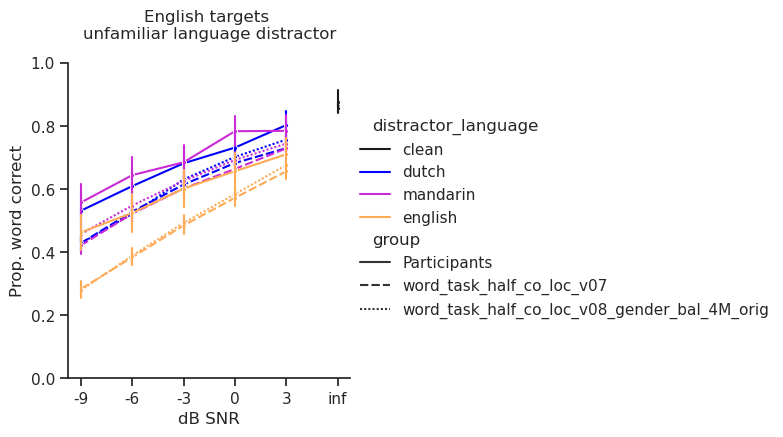

In [179]:
cmap = sns.color_palette("gnuplot2", n_colors=3)

palette = {lang:cmap[ix] for ix, lang in enumerate(['dutch', 'mandarin', 'english'])}
palette['clean'] = 'k'
g = sns.relplot(data=combined_results, x='snr', y='accuracy', # hue='gender_cond',
                # col_wrap=3,
                # hue='Distractor Sex', #
                # col='sex_cond',
                style='group', #style_order = ['Participants', 'Model'],
                hue='distractor_language', hue_order = ['clean', 'dutch', 'mandarin', 'english'],
                kind='line', marker='.',
                # color='k',
                palette=palette,
                height=4, aspect=1.1,
                err_style='bars', 
                errorbar=('se', 2),)

# set labels 
g.set_axis_labels("dB SNR", "Prop. word correct")
g.set_titles("{col_name}")

# add xtick labels 
x_tick_locs = sorted(all_model_results.snr.unique())
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'
for ax in g.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)

# g.ax.set_xticks(ticks=results.snr.unique())
# g.set_xticklabels(results.snr.unique())
plt.title('English targets \nunfamiliar language distractor', y=1.05)
plt.ylim(0,1)

(0.0, 1.0)

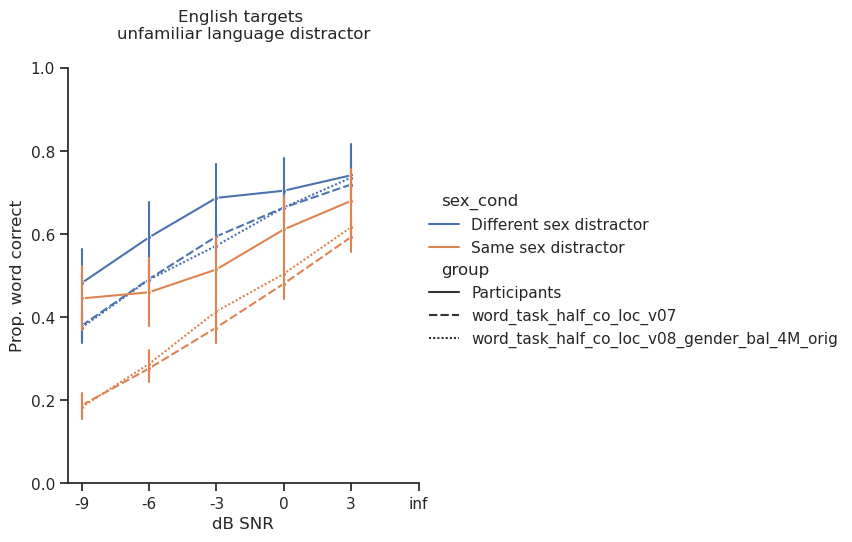

In [180]:
cmap = sns.color_palette("gnuplot2", n_colors=3)

palette = {lang:cmap[ix] for ix, lang in enumerate(['dutch', 'mandarin', 'english'])}
palette['clean'] = 'k'
to_plot = combined_results[combined_results.distractor_language == 'english']
g = sns.relplot(data=to_plot, x='snr', y='accuracy', # hue='gender_cond',
                # col_wrap=3,
                # hue='Distractor Sex', #
                # col='sex_cond',
                style='group', #style_order = ['Participants', 'Model'],
                hue='sex_cond',# hue_order = ['clean', 'dutch', 'mandarin', 'english'],
                kind='line', marker='.',
                # color='k',
                # palette=palette,
                # height=4, aspect=1.1,
                err_style='bars', 
                errorbar=('se', 2),)

# set labels 
g.set_axis_labels("dB SNR", "Prop. word correct")
g.set_titles("{col_name}")

# add xtick labels 
x_tick_locs = sorted(all_model_results.snr.unique())
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'
for ax in g.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)

# g.ax.set_xticks(ticks=results.snr.unique())
# g.set_xticklabels(results.snr.unique())
plt.title('English targets \nunfamiliar language distractor', y=1.05)
plt.ylim(0,1)

In [181]:
combined_results

,snr,id_subject,distractor_language,sex_cond,gender,accuracy,count,confusions,group
0,-9,56366e43dc62e50011cb4ca1,dutch,Different sex distractor,female,1.000000,3.0,0.0,Participants
1,-9,56366e43dc62e50011cb4ca1,dutch,Different sex distractor,male,0.333333,3.0,0.0,Participants
2,-9,56366e43dc62e50011cb4ca1,dutch,Same sex distractor,female,1.000000,2.0,0.0,Participants
3,-9,56366e43dc62e50011cb4ca1,dutch,Same sex distractor,male,0.500000,2.0,0.0,Participants
4,-9,56366e43dc62e50011cb4ca1,english,Different sex distractor,female,0.666667,3.0,0.0,Participants
...,...,...,...,...,...,...,...,...,...
53058,3,NaN,mandarin,Same sex distractor,male,0.000000,NaN,0.0,word_task_half_co_loc_v08_gender_bal_4M_orig
53059,3,NaN,mandarin,Different sex distractor,male,1.000000,NaN,0.0,word_task_half_co_loc_v08_gender_bal_4M_orig
53060,3,NaN,mandarin,Same sex distractor,male,1.000000,NaN,0.0,word_task_half_co_loc_v08_gender_bal_4M_orig
53061,3,NaN,mandarin,Different sex distractor,male,1.000000,NaN,0.0,word_task_half_co_loc_v08_gender_bal_4M_orig


(0.0, 1.0)

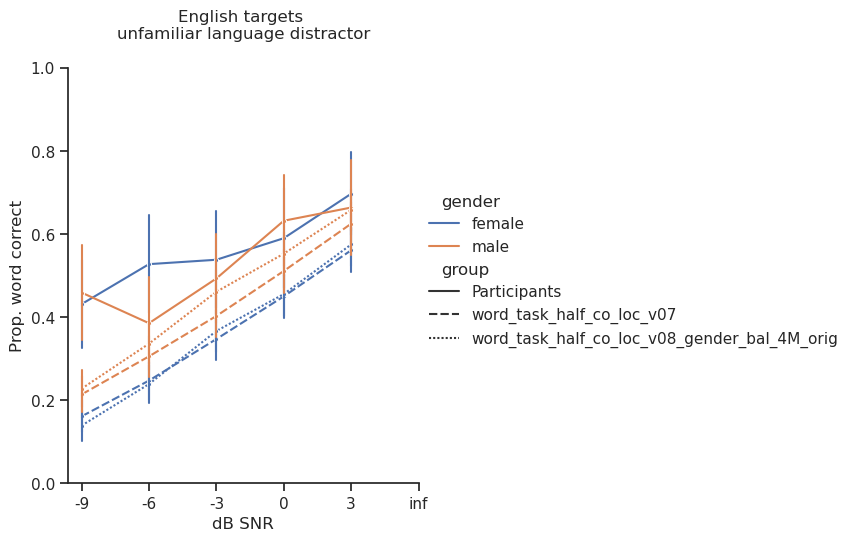

In [182]:
cmap = sns.color_palette("gnuplot2", n_colors=3)

palette = {lang:cmap[ix] for ix, lang in enumerate(['dutch', 'mandarin', 'english'])}
palette['clean'] = 'k'
to_plot = combined_results[(combined_results.distractor_language == 'english')
							& (combined_results.sex_cond == "Same sex distractor")]
g = sns.relplot(data=to_plot, x='snr', y='accuracy', # hue='gender_cond',
                # col_wrap=3,
                # hue='Distractor Sex', #
                # col='sex_cond',
                style='group', #style_order = ['Participants', 'Model'],
                hue='gender',# hue_order = ['clean', 'dutch', 'mandarin', 'english'],
                kind='line', marker='.',
                # color='k',
                # palette=palette,
                # height=4, aspect=1.1,
                err_style='bars', 
                errorbar=('se', 2),)

# set labels 
g.set_axis_labels("dB SNR", "Prop. word correct")
g.set_titles("{col_name}")

# add xtick labels 
x_tick_locs = sorted(all_model_results.snr.unique())
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'
for ax in g.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)

# g.ax.set_xticks(ticks=results.snr.unique())
# g.set_xticklabels(results.snr.unique())
plt.title('English targets \nunfamiliar language distractor', y=1.05)
plt.ylim(0,1)

#### Scatter plot 

In [99]:
scatter_results = combined_results.groupby(['group', 'distractor_language', 'snr']).agg({"accuracy":['mean', 'sem'], "confusions":['mean', 'sem']}).reset_index()
scatter_results.distractor_language =  scatter_results.distractor_language.replace('clean', 'No distractor')
scatter_results.distractor_language  = scatter_results.distractor_language.str.title()

In [100]:
combined_results.id_subject.unique().shape

(47,)

In [101]:
# scatter_results

In [102]:
combined_results.id_subject.nunique()

46

In [103]:
from scipy import stats

In [104]:
model_res

group distractor_language snr  \
                                                                           
38  word_task_half_co_loc_v08_gender_bal_4M_orig             English  -9   
39  word_task_half_co_loc_v08_gender_bal_4M_orig             English  -6   
40  word_task_half_co_loc_v08_gender_bal_4M_orig             English  -3   
41  word_task_half_co_loc_v08_gender_bal_4M_orig             English   0   
42  word_task_half_co_loc_v08_gender_bal_4M_orig             English   3   

    accuracy           confusions            
        mean       sem       mean       sem  
38  0.279167  0.011825   0.270139  0.011705  
39  0.388889  0.012851   0.197222  0.010489  
40  0.493056  0.013179   0.131944  0.008922  
41  0.584028  0.012993   0.084028  0.007313  
42  0.676389  0.012333   0.051389  0.005820

0 0
5 5
5 5
5 5
0 0
5 5
5 5
5 5


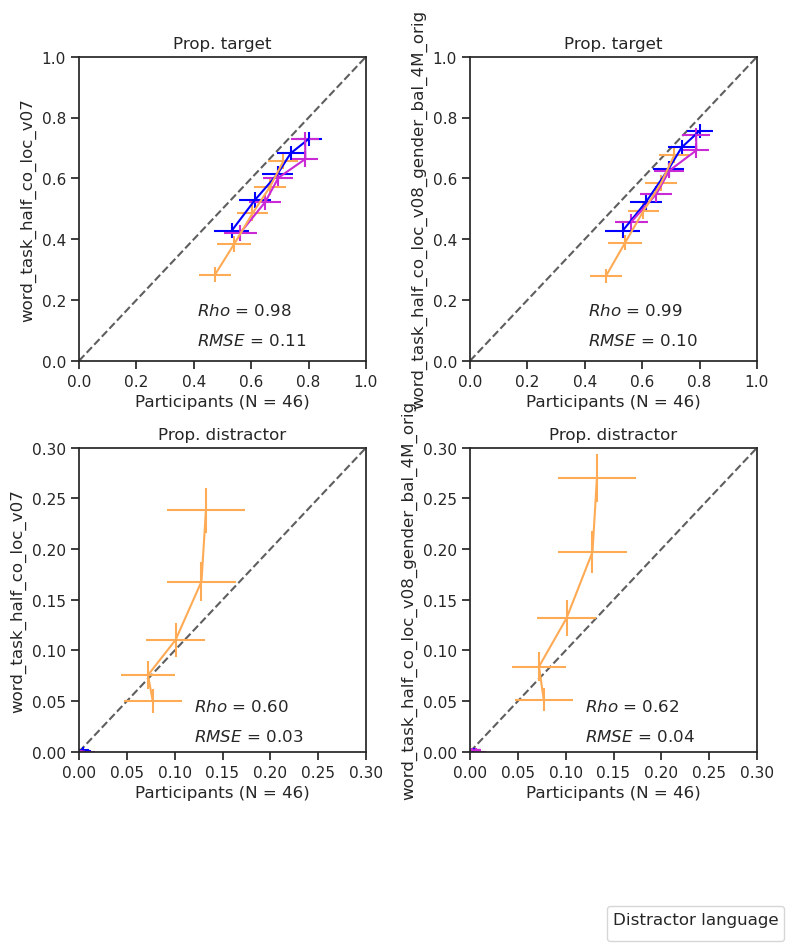

In [105]:
# plot human performance against model performance
cmap = sns.color_palette("gnuplot2", n_colors=3)
N_parts = combined_results.id_subject.nunique()

models  = [m for m in combined_results['group'].unique() if m != 'Participants']
n_models = len(models)
languages = ['No distractor', 'Dutch', 'Mandarin', 'English']

palette = {lang:cmap[ix] for ix, lang in enumerate(['Dutch', 'Mandarin', 'English'])}
palette['No distractor'] = 'k'


fig, axs =  plt.subplots(2, n_models, figsize=(4 * n_models, 8 ))

sns.set_theme(style="ticks")
# fontsize=18
# make  palette for texture labels

x = y = np.linspace(0,1,5)
# plot data with 2 sem error bars


human_df = scatter_results[scatter_results.group == 'Participants']
for ix, model in enumerate(models):
	model_df = scatter_results[scatter_results.group == model]
	axs[0, ix].plot(x,y, ls='dashed', color='k', alpha=0.7)
	axs[1, ix].plot(x,y, ls='dashed', color='k', alpha=0.7)

	for language in languages:
		human_res = human_df[human_df.distractor_language == language]
		model_res = model_df[model_df.distractor_language == language]
		print(len(human_res), len(model_res))
		axs[0, ix].errorbar(x=human_res['accuracy']['mean'],
				y=model_res['accuracy']['mean'],
				xerr = human_res['accuracy']['sem']*2,
				yerr=model_res['accuracy']['sem']*2,
				# label=language,
				color=palette[language],
			#     marker=marker_dict[row['target_harmonicity']]
			)   

		axs[1, ix].errorbar(x=human_res['confusions']['mean'],
				y=model_res['confusions']['mean'],
				xerr = human_res['confusions']['sem']*2,
				yerr=model_res['confusions']['sem']*2,
				label=language,
				color=palette[language],
			#     marker=marker_dict[row['target_harmonicity']]
			)   
            # marker='o', linestyle=None, ms=3, elinewidth=2.5,)
# accs = sns.scatterplot(data=to_plot, x='participant_accuracy', y='model_accuracy',
#         hue='distractor_harmonicity', palette=palette_dict, style='target_harmonicity', ax=axs[0])


# confs = sns.scatterplot(data=to_plot, x='participant_confusions', y='model_confusions',
#         hue='distractor_harmonicity', palette=palette_dict, style='target_harmonicity', ax=axs[1],
#         )

# sns.despine()
# accs.legend().remove()


	axs[0, ix].set_xlim(0,1)
	axs[0, ix].set_ylim(0,1)

	axs[0, ix].set_xticks(np.linspace(0,1,6))
	axs[0, ix].set_yticks(np.linspace(0,1,6))

	axs[1, ix].set_xlim(0,.3)
	axs[1, ix].set_ylim(0,.3)


	axs[0, ix].set_title("Prop. target")
	axs[0, ix].set_xlabel(f'Participants (N = {N_parts})')
	axs[0, ix].set_ylabel(model)

	axs[1, ix].set_title("Prop. distractor")
	axs[1, ix].set_xlabel(f'Participants (N = {N_parts})')
	axs[1, ix].set_ylabel(model)

	# Add error annotations 
	# acc errors 
	res = stats.spearmanr(human_df['accuracy']['mean'].values,  model_df['accuracy']['mean'].values)
	rho = res.correlation
	axs[0, ix].annotate(f"$Rho$ = {rho:.2f}", (0.41, 0.15),)# fontsize=14)
	# r_model_human, p = stats.pearsonr(human_df['accuracy']['mean'].values,  model_df['accuracy']['mean'].values)
	# axs[0].annotate(f"$r$ = {r_model_human:.2f}", (0.6, 0.12), fontsize=14)

	samp_rmse = np.sqrt(np.mean((human_df['accuracy']['mean'].values - model_df['accuracy']['mean'].values)**2))
	axs[0, ix].annotate(f"$RMSE$ = {samp_rmse:.2f}", (0.41, 0.05),)# fontsize=14)
	# conf errors
	res = stats.spearmanr(human_df['confusions']['mean'].values,  model_df['confusions']['mean'].values)
	rho = res.correlation
	axs[1, ix].annotate(f"$Rho$ = {rho:.2f}", (0.12, 0.04), )#fontsize=14)   # old xy coords ( 0.25, 0.05)
	# r_model_human, p  = stats.pearsonr(to_plot["participant_confusions"].values,  to_plot['model_confusions'].values)
	# axs[1].annotate(f"$r$ = {r_model_human:.2f}", (0.17, 0.03), fontsize=14)   # old xy coords ( 0.25, 0.05)
	samp_rmse = np.sqrt(np.mean((human_df['confusions']['mean'].values - model_df['confusions']['mean'].values)**2))
	axs[1, ix].annotate(f"$RMSE$ = {samp_rmse:.2f}", (0.12, 0.01), )#fontsize=14) # old xy coords ( 0.25, 0.025)




# sns.move_legend(confs, title='', loc="center right", 
#                  bbox_to_anchor=(2.5, .5),
#                 frameon=False, )#title_size=fontsize, fontsize=fontsize)

lines_labels = [ax.get_legend_handles_labels() for ax in [axs[0,0]]]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
fig.legend(lines, labels,
            bbox_transform=fig.transFigure,  ncol=4, title='Distractor language',  bbox_to_anchor=(1, -.1),)

# plt.subplots_adjust(wspace=0.4)

plt.tight_layout()

#### Old model-only plots

(0.0, 1.0)

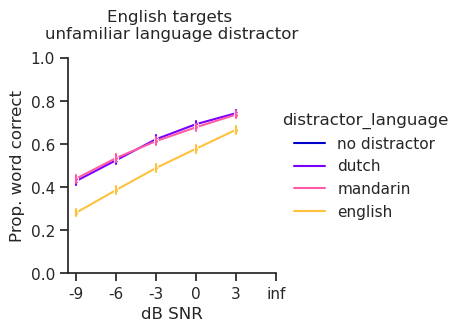

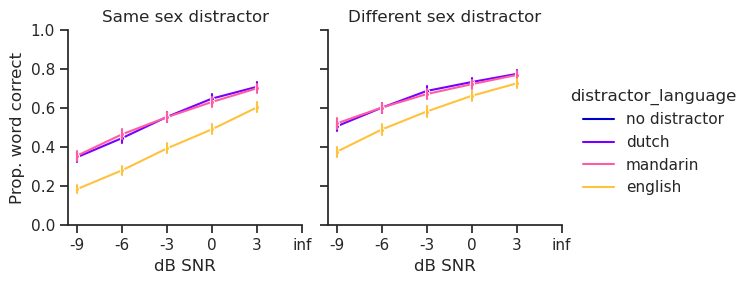

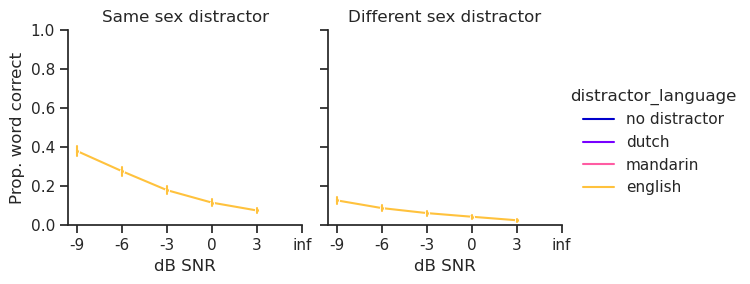

In [106]:
# results = all_results[all_results.snr.isin([0.25, 0.5,1,2])]

g = sns.relplot(data=all_model_results, x='snr', y='accuracy', # hue='gender_cond',
                # col_wrap=3,
                # hue='Distractor Sex', #
                # col='sex_cond',
                hue='distractor_language', hue_order = ['no distractor', 'dutch', 'mandarin', 'english'],
                kind='line', marker='.',
                # color='k',
                palette='gnuplot2',
                height=3, aspect=1.1,
                err_style='bars', 
                errorbar=('se', 2),)

# set labels 
g.set_axis_labels("dB SNR", "Prop. word correct")
g.set_titles("{col_name}")

# add xtick labels 
x_tick_locs = sorted(all_model_results.snr.unique())
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'
for ax in g.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)

# g.ax.set_xticks(ticks=results.snr.unique())
# g.set_xticklabels(results.snr.unique())
plt.title('English targets \nunfamiliar language distractor', y=1.05)
plt.ylim(0,1)
# group_order = [ f"Participants (N={part_summary_df.id_subject.nunique()})", 'Model']
# add markers to relplot
g = sns.relplot(data=all_model_results, x='snr', y='accuracy', # hue='gender_cond',
                # col_wrap=3,
                # hue='Distractor Sex', #
                col='sex_cond',
                hue='distractor_language', hue_order = ['no distractor', 'dutch', 'mandarin', 'english'],
                kind='line', marker='.',
                # color='k',
                palette='gnuplot2',
                height=3, aspect=1,
                err_style='bars', 
                errorbar=('se', 2),)

# set labels 
g.set_axis_labels("dB SNR", "Prop. word correct")
g.set_titles("{col_name}")

# add xtick labels 
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'
for ax in g.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)

# g.ax.set_xticks(ticks=results.snr.unique())
# g.set_xticklabels(results.snr.unique())

plt.ylim(0,1)
# plt.suptitle(f"Using 1 disractor at 0 dB SNR", y=1.05)

# results = all_results[all_results.snr.isin([0.25, 0.5,1,2])]


# group_order = [ f"Participants (N={part_summary_df.id_subject.nunique()})", 'Model']
# add markers to relplot
g = sns.relplot(data=all_model_results[all_model_results.distractor_language == 'english'], x='snr', y='confusions', # hue='gender_cond',
                # col_wrap=3,
                # hue='Distractor Sex', #
                col='sex_cond',
                hue='distractor_language', hue_order = ['no distractor', 'dutch', 'mandarin', 'english'],
                kind='line', marker='.',
                # color='k',
                palette='gnuplot2',
                height=3, aspect=1,
                err_style='bars', 
                errorbar=('se', 2),)

# set labels 
g.set_axis_labels("dB SNR", "Prop. word correct")
g.set_titles("{col_name}")

# add xtick labels 
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'
for ax in g.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)

# g.ax.set_xticks(ticks=results.snr.unique())
# g.set_xticklabels(results.snr.unique())

plt.ylim(0,1)
# plt.suptitle(f"Using 1 disractor at 0 dB SNR", y=1.05)


___
### Sanity-check english portion to make sure accuracy and confusions similar to old data

In [32]:
melted_results = pd.melt(all_model_results[all_model_results.distractor_language == 'english'], id_vars=['snr', 'sex_cond'],
        value_vars=['accuracy', 'confusions'],
        value_name = 'hits',
        var_name = 'stream')

In [33]:
melted_results

,snr,sex_cond,stream,hits
0,-3,Same sex distractor,accuracy,0
1,-3,Different sex distractor,accuracy,0
2,-3,Same sex distractor,accuracy,1
3,-3,Different sex distractor,accuracy,1
4,-3,Different sex distractor,accuracy,1
...,...,...,...,...
14395,3,Same sex distractor,confusions,0
14396,3,Different sex distractor,confusions,0
14397,3,Same sex distractor,confusions,1
14398,3,Different sex distractor,confusions,0


(0.0, 1.0)

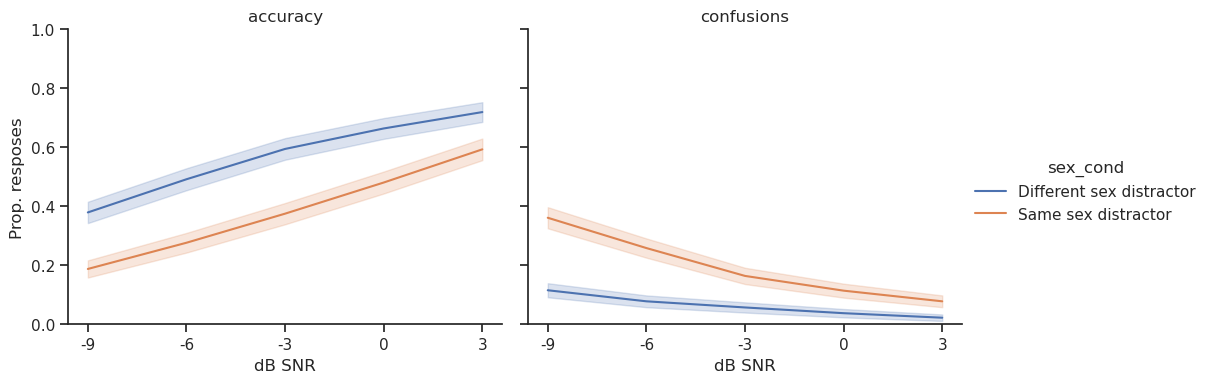

In [34]:
# results = all_results[all_results.snr.isin([0.25, 0.5,1,2])]


# group_order = [ f"Participants (N={part_summary_df.id_subject.nunique()})", 'Model']
# add markers to relplot
g = sns.relplot(data=melted_results, x='snr', y='hits', # hue='gender_cond',
                # col_wrap=3,
                hue='sex_cond', hue_order=[ 'Different sex distractor', 'Same sex distractor'],
                col='stream',
                # style='Distractor Playback', style_order = ['Forward', 'Time Reversed'],
                kind='line', marker='',
                # color='k',
                height=4, aspect=1.25,
                # err_style='bars', 
                errorbar=('se', 2),)

# set labels 
g.set_axis_labels("dB SNR", "Prop. resposes")
g.set_titles("{col_name}")

# add xtick labels 

# add xtick labels 
x_tick_locs = melted_results.snr.unique()
x_tick_labels = [str(x) for x in x_tick_locs]
# x_tick_labels[-1] = 'inf'
for ax in g.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)

# g.ax.set_xticks(ticks=results.snr.unique())
# g.set_xticklabels(results.snr.unique())

plt.ylim(0,1)
# plt.suptitle(f"Using 1 disractor at 0 dB SNR", y=1.05)


In [27]:
### Sanity check dataloader 
from corpus.swc_mono_test import SWCMonoTestSetUnfamililarLanguage

stim_manifest_path = '/om/user/imgriff/datasets/human_distractor_language_2024/final_stim_manifest_w_cue_tg_lang_dists.pdpkl'

sr=44_100
language = 'english'
label_type = 'CV'
dataset = SWCMonoTestSetUnfamililarLanguage(manifest_path=stim_manifest_path,
                                                model_sr=sr,
                                                distractor_language=language,
                                                label_type=label_type)

cue, target, distractor, label = dataset[0]

Evaluating using distractors from: distractor_src_fn


In [44]:
datset_df = dataset.dataset

In [46]:
class_map = dataset.word_2_class

In [51]:
class_map['attack']

47

In [45]:
datset_df

array([['/om/user/imgriff/datasets/spatial_audio_pipeline/assets/human_attn_experiment_v00/target_excerpts/these_1904-cc.wav',
        '/om/user/imgriff/datasets/spatial_audio_pipeline/assets/human_attn_experiment_v00/cue_excerpts/dramatic_1904-cc.wav',
        '/om/user/imgriff/datasets/spatial_audio_pipeline/assets/human_attn_experiment_v00/distractor_excerpts/either_popularoutcast.wav',
        703],
       ['/om/user/imgriff/datasets/spatial_audio_pipeline/assets/human_attn_experiment_v00/target_excerpts/these_1904-cc.wav',
        '/om/user/imgriff/datasets/spatial_audio_pipeline/assets/human_attn_experiment_v00/cue_excerpts/dramatic_1904-cc.wav',
        '/om/user/imgriff/datasets/spatial_audio_pipeline/assets/human_attn_experiment_v00/distractor_excerpts/seven_matthewdgonzalez.wav',
        703],
       ['/om/user/imgriff/datasets/spatial_audio_pipeline/assets/human_attn_experiment_v00/target_excerpts/simply_1904-cc.wav',
        '/om/user/imgriff/datasets/spatial_audio_pipeline

In [28]:
import IPython.display as ipd


In [30]:
ipd.display(ipd.Audio(cue, rate=sr))
ipd.display(ipd.Audio(target, rate=sr))
ipd.display(ipd.Audio(distractor, rate=sr))
label

703